# Subplot

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

In [3]:
df.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,None,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."


job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

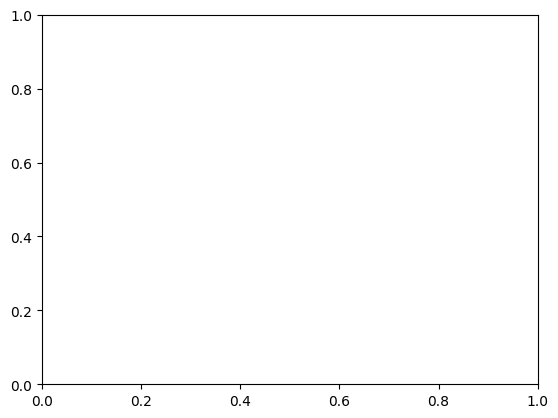

In [ ]:
# this helps to create the canvas where every one of the graphics are gonna be compiled 
fig, ax = plt.subplots()




job_schedule_type
Full-time                                701727
Contractor                                34793
Internship                                 8742
Part-time                                  7881
Full-time and Part-time                    6287
Full-time and Temp work                    2603
Full-time and Internship                   2340
Full-time and Contractor                   2292
Contractor and Temp work                   2283
Temp work                                  2169
Full-time, Part-time, and Internship        264
Part-time and Internship                    255
Temp work and Internship                    211
Full-time, Contractor, and Temp work        194
Full-time, Temp work, and Internship        173
Part-time and Contractor                    160
Full-time, Part-time, and Temp work         131
Full-time, Part-time, and Contractor        119
Part-time and Temp work                     111
Pekerjaan tetap                              59
Volunteer             

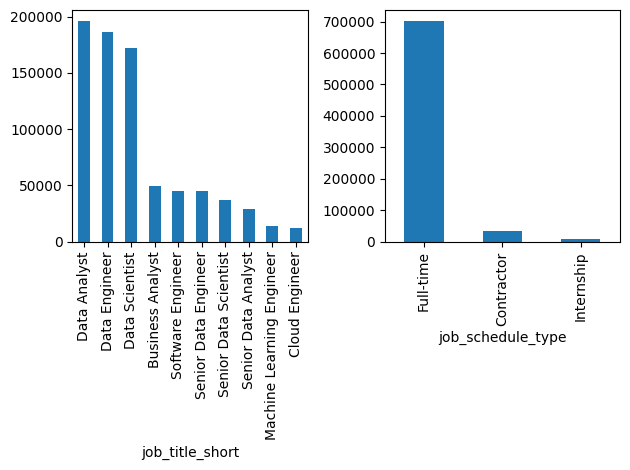

In [19]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax = ax[0] )
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax = ax[1])

# this is for help with the spaces between the figure
fig.tight_layout()

In [ ]:
Top_3_Skills = df['job_title_short'].value_counts().head(3).index
Top_3_Skills

Index(['Data Analyst', 'Data Engineer', 'Data Scientist'], dtype='object', name='job_title_short')

In [28]:
Explode = df.explode('job_skills')
Explode.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,None,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."


In [72]:
test1 = Explode.groupby(['job_title_short', 'job_skills']).size().sort_values(ascending=False)
test1[Top_3_Skills]
test1 = pd.DataFrame(test1)
test1

0
job_title_short   job_skills          
Data Scientist    python        113711
Data Engineer     sql           113130
                  python        108022
Data Analyst      sql            92428
Data Scientist    sql            78982
...                                ...
Business Analyst  digitalocean       1
Software Engineer visualbasic        1
Business Analyst  codecommit         1
                  chainer            1
                  capacitor          1

[2256 rows x 1 columns]

In [75]:
test1 = test1.sort_values(by=0, ascending=False)

In [77]:
Role = 'Data_Analyst'

final_Data_Analyst = test1[test1['job_title_short']== Role].head(10)
final_Data_Analyst

,job_title_short,job_skills,0


In [86]:
test1['count']= test1[0]
test1 = test1.drop(columns=[0])

In [89]:
test1

,job_title_short,job_skills,count
0,Data Scientist,python,113711
1,Data Engineer,sql,113130
2,Data Engineer,python,108022
3,Data Analyst,sql,92428
4,Data Scientist,sql,78982
...,...,...,...
2251,Business Analyst,digitalocean,1
2252,Software Engineer,visualbasic,1
2253,Business Analyst,codecommit,1
2254,Business Analyst,chainer,1


In [92]:
job_title = 'Data Analyst'
top_skills = 10

df_skill_final_DA = test1[test1['job_title_short'] == job_title].head(top_skills)
df_skill_final_DA

,job_title_short,job_skills,count
3,Data Analyst,sql,92428
5,Data Analyst,excel,66860
9,Data Analyst,python,57190
11,Data Analyst,tableau,46455
12,Data Analyst,power bi,39380
14,Data Analyst,r,29996
22,Data Analyst,sas,27998
57,Data Analyst,powerpoint,13822
58,Data Analyst,word,13562
64,Data Analyst,sap,11280


In [93]:
job_title = 'Data Scientist'
top_skills = 10

df_skill_final_DS = test1[test1['job_title_short'] == job_title].head(top_skills)
df_skill_final_DS

,job_title_short,job_skills,count
0,Data Scientist,python,113711
4,Data Scientist,sql,78982
8,Data Scientist,r,59566
15,Data Scientist,sas,29534
16,Data Scientist,tableau,29445
25,Data Scientist,aws,26256
28,Data Scientist,spark,24286
31,Data Scientist,azure,21664
34,Data Scientist,tensorflow,19153
40,Data Scientist,excel,17545


In [94]:
job_title = 'Data Engineer'
top_skills = 10

df_skill_final_DE = test1[test1['job_title_short'] == job_title].head(top_skills)
df_skill_final_DE

,job_title_short,job_skills,count
1,Data Engineer,sql,113130
2,Data Engineer,python,108022
6,Data Engineer,aws,62049
7,Data Engineer,azure,60674
10,Data Engineer,spark,53656
13,Data Engineer,java,35559
17,Data Engineer,kafka,29073
19,Data Engineer,hadoop,28815
20,Data Engineer,scala,28716
23,Data Engineer,databricks,27477


Text(0.5, 1.0, 'Data Analyst by top skills')

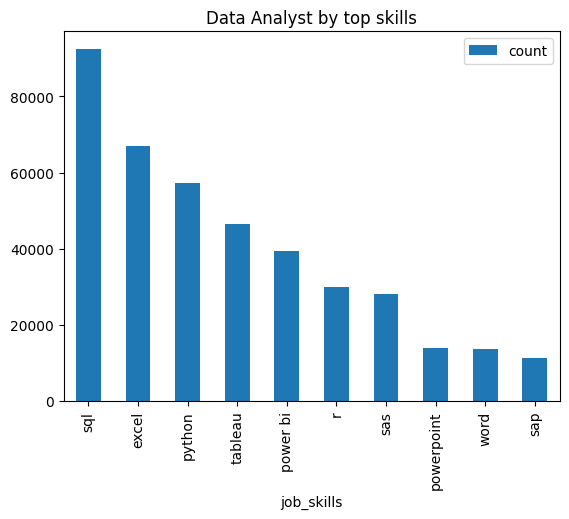

In [102]:
df_skill_final_DA.plot(kind='bar', x='job_skills')
plt.title('Data Analyst by top skills')

Text(0.5, 1.0, 'Data Scientist by top skills')

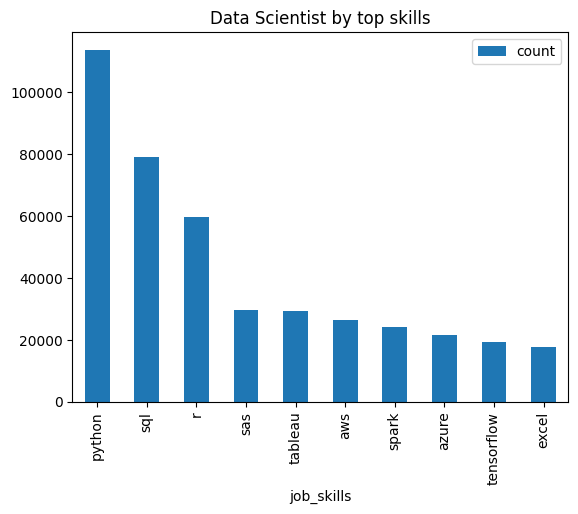

In [103]:
df_skill_final_DS.plot(kind='bar', x='job_skills')
plt.title('Data Scientist by top skills')

Text(0.5, 1.0, 'Data Engineer by top skills')

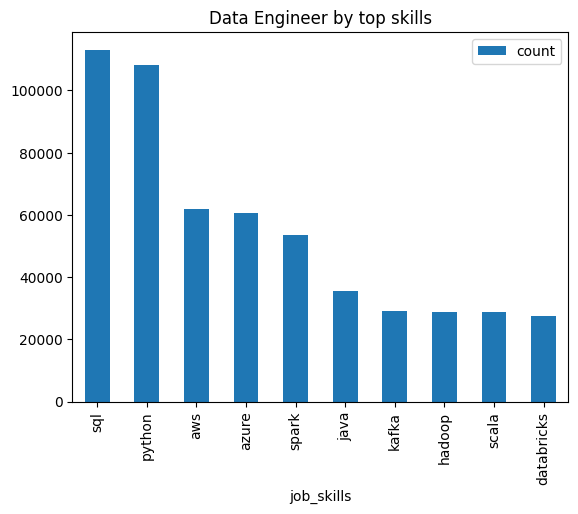

In [104]:
df_skill_final_DE.plot(kind='bar', x='job_skills')
plt.title('Data Engineer by top skills')

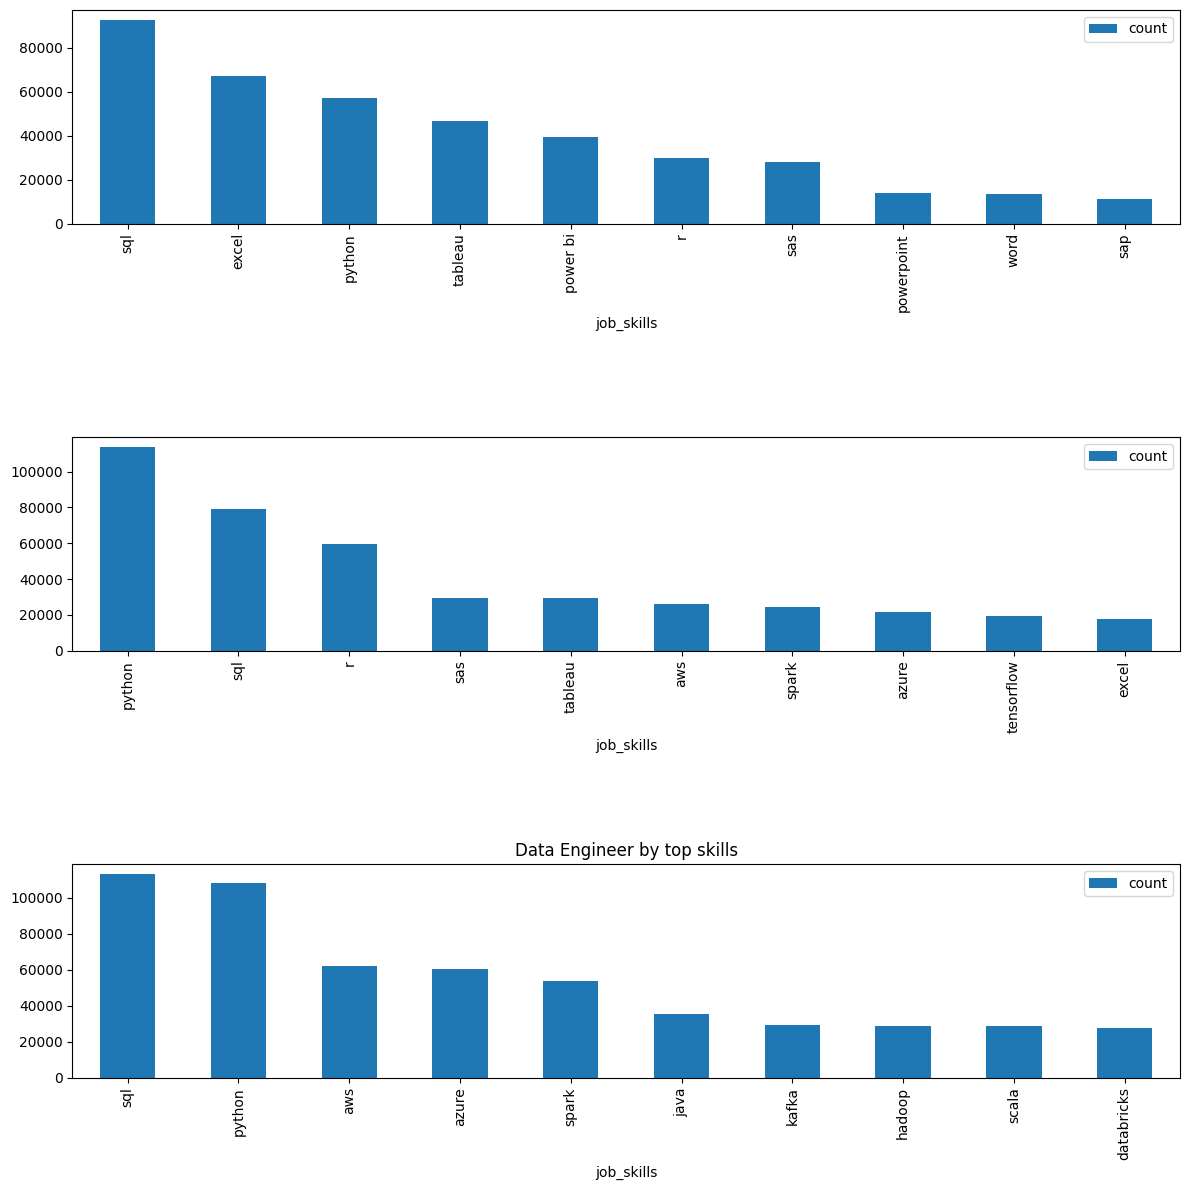

In [112]:
fig, ax = plt.subplots(3,1, figsize=(12, 12))

df_skill_final_DA.plot(kind='bar', x='job_skills', ax=ax[0])
plt.title('Data Analyst by top skills')

df_skill_final_DS.plot(kind='bar', x='job_skills', ax=ax[1])
plt.title('Data Scientist by top skills')

df_skill_final_DE.plot(kind='bar', x='job_skills', ax=ax[2])
plt.title('Data Engineer by top skills')

plt.tight_layout()
plt.subplots_adjust(hspace=1)

In [1]:
# Version #2 of the subplot with the dataset performed by the explode method on chapter 11

In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
def clean_list (skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
df['job_skills'] = df['job_skills'].apply(clean_list)

In [4]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending = False, inplace = True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
1723,shogun,Business Analyst,1
447,delphi,Senior Data Scientist,1
2124,visualbasic,Software Engineer,1
450,digitalocean,Business Analyst,1


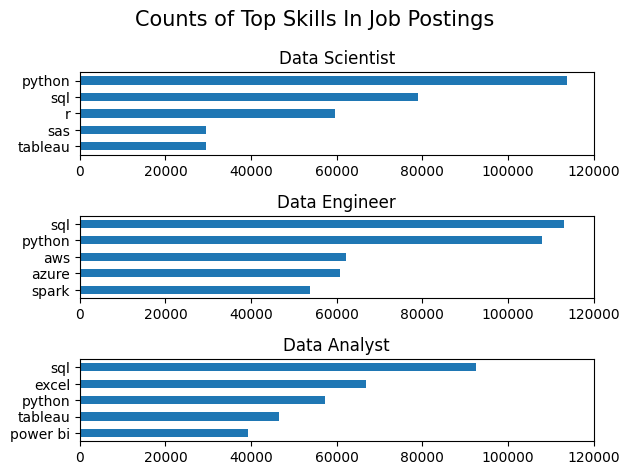

In [13]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

fig, ax = plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000)


fig.suptitle('Counts of Top Skills In Job Postings', fontsize = 15)
fig.tight_layout()        